In [15]:
from pathlib import Path

import prism

from imagematerials.eol import eol_preprocess
from imagematerials.factory import ModelFactory, Sector
from imagematerials.model import (
    EndOfLife,
    GenericMaterials,
    GenericStocks,
    Maintenance,
    MaterialIntensities,
    RestOf
)
from imagematerials.preprocessing import get_preprocessing_data
import numpy as np



In [16]:
from imagematerials.rest_of import rest_of_preprocessing

In [17]:
image_scenario = "SSP2_M_CP"
climate_policy_scenario_dir = Path("..", "data", "raw", "image", image_scenario)

In [18]:
import xarray as xr
path = scenario_base_path = Path("../data/raw/rest-of/gompertz_values")
xr_gompertz = xr.open_dataset(scenario_base_path / "coefs_gompertz.nc", engine="netcdf4")

In [19]:
region_values = [str(r) for r in xr_gompertz['Region'].values]

In [20]:
region_values
region_values_sorted = sorted(region_values, key=lambda x: int(x))
data = xr_gompertz['gompertz_coefs'].sel(Region=region_values_sorted)


In [21]:
xr_gompertz.to_array()
da = xr_gompertz.to_array().squeeze("variable")
da = xr_gompertz.to_array().isel(variable=0).drop_vars("variable")

# sort regions from 1 to 26
da = da.sel(Region=sorted(da.coords["Region"].values, key=lambda x: int(x)))

In [22]:
da

<xarray.DataArray (coef: 3, Region: 26, material: 3)> Size: 2kB
array([[[2.34863559e-04, 1.30914983e-01, 3.85363829e-01],
        [2.34863559e-04, 1.30914983e-01, 2.26171458e-01],
        [2.34863559e-04, 1.30914983e-01, 2.26171458e-01],
        [9.22650707e-03, 2.35406897e-01, 2.78591841e-01],
        [9.22650707e-03, 2.35406897e-01, 2.78591841e-01],
        [9.22650707e-03, 2.35406897e-01, 2.78591841e-01],
        [9.22650707e-03, 2.35406897e-01, 2.78591841e-01],
        [9.22650707e-03, 2.35406897e-01, 2.78591841e-01],
        [9.22650707e-03, 2.35406897e-01, 2.78591841e-01],
        [9.22650707e-03, 2.35406897e-01, 2.78591841e-01],
        [1.55648561e-02, 1.30914983e-01, 2.26171458e-01],
        [1.55648561e-02, 2.35406897e-01, 2.78591841e-01],
        [1.55648561e-02, 2.35406897e-01, 3.85363829e-01],
        [1.42407332e-02, 2.35406897e-01, 2.78591841e-01],
        [1.42407332e-02, 2.35406897e-01, 2.78591841e-01],
        [1.42407332e-02, 8.00000000e-01, 3.85363829e-01],
        [2.56876296e-02, 2.35406897e-01, 2.78591841e-01],
        [9.22650707e-03, 2.35406897e-01, 2.78591841e-01],
        [9.22650707e-03, 2.35406897e-01, 7.30253853e-01],
        [2.56876296e-02, 8.00000000e-01, 7.30253853e-01],
...
        [4.41609599e+00, 7.15848185e+00, 1.84756103e+00],
        [4.41609599e+00, 7.15848185e+00, 1.84756103e+00],
        [4.41609599e+00, 7.15848185e+00, 1.84756103e+00],
        [4.41609599e+00, 7.15848185e+00, 1.84756103e+00],
        [1.04366863e+00, 5.18256791e+00, 2.28740715e+00],
        [1.04366863e+00, 7.15848185e+00, 1.84756103e+00],
        [1.04366863e+00, 7.15848185e+00, 2.50208566e+00],
        [1.00000000e+01, 7.15848185e+00, 1.84756103e+00],
        [1.00000000e+01, 7.15848185e+00, 1.84756103e+00],
        [1.00000000e+01, 6.54090606e+00, 2.50208566e+00],
        [2.19190188e+00, 7.15848185e+00, 1.84756103e+00],
        [4.41609599e+00, 7.15848185e+00, 1.84756103e+00],
        [4.41609599e+00, 7.15848185e+00, 1.65112675e+00],
        [2.19190188e+00, 6.54090606e+00, 1.65112675e+00],
        [4.41609599e+00, 7.15848185e+00, 1.84756103e+00],
        [4.41609599e+00, 7.15848185e+00, 1.84756103e+00],
        [1.04366863e+00, 5.18256791e+00, 2.50208566e+00],
        [1.04366863e+00, 5.18256791e+00, 2.28740715e+00],
        [4.41609599e+00, 7.15848185e+00, 1.84756103e+00],
        [4.41609599e+00, 7.15848185e+00, 1.84756103e+00]]])
Coordinates:
  * Region    (Region) <U2 208B '1' '2' '3' '4' '5' ... '22' '23' '24' '25' '26'
  * material  (material) <U9 108B 'Aluminium' 'Cement' 'Steel'
  * coef      (coef) <U1 12B 'a' 'b' 'c'

In [23]:
da.sel(material = 'Steel')

<xarray.DataArray (coef: 3, Region: 26)> Size: 624B
array([[ 0.38536383,  0.22617146,  0.22617146,  0.27859184,  0.27859184,
         0.27859184,  0.27859184,  0.27859184,  0.27859184,  0.27859184,
         0.22617146,  0.27859184,  0.38536383,  0.27859184,  0.27859184,
         0.38536383,  0.27859184,  0.27859184,  0.73025385,  0.73025385,
         0.27859184,  0.27859184,  0.38536383,  0.22617146,  0.27859184,
         0.27859184],
       [ 4.38447193, 10.        , 10.        ,  2.97942469,  2.97942469,
         2.97942469,  2.97942469,  2.97942469,  2.97942469,  2.97942469,
        10.        ,  2.97942469,  4.38447193,  2.97942469,  2.97942469,
         4.38447193,  2.97942469,  2.97942469,  3.25403311,  3.25403311,
         2.97942469,  2.97942469,  4.38447193, 10.        ,  2.97942469,
         2.97942469],
       [ 2.50208566,  2.28740715,  2.28740715,  1.84756103,  1.84756103,
         1.84756103,  1.84756103,  1.84756103,  1.84756103,  1.84756103,
         2.28740715,  1.84756103,  2.50208566,  1.84756103,  1.84756103,
         2.50208566,  1.84756103,  1.84756103,  1.65112675,  1.65112675,
         1.84756103,  1.84756103,  2.50208566,  2.28740715,  1.84756103,
         1.84756103]])
Coordinates:
  * Region    (Region) <U2 208B '1' '2' '3' '4' '5' ... '22' '23' '24' '25' '26'
    material  <U9 36B 'Steel'
  * coef      (coef) <U1 12B 'a' 'b' 'c'

In [24]:
scenario_base_path = Path("../data/raw") / 'circular_economy_scenarios'

# Define the complete timeline, including historic tail
# time_start = prep_data["stocks"].coords["Time"].min().values
time_start = 1960
complete_timeline = prism.Timeline(time_start, 2060, 1)
simulation_timeline = prism.Timeline(1970, 2060, 1)


bld_sector = get_preprocessing_data("buildings", Path("..", "data", "raw"), 
                                    climate_policy_scenario_dir, 
                                    circular_economy_scenario_dirs = None) 
vhc_sector = get_preprocessing_data("vehicles", Path("..", "data", "raw"), 
                                    climate_policy_scenario_dir, 
                                    circular_economy_scenario_dirs = None)
rest_sector = rest_of_preprocessing(Path("..", "data", "raw"), 
                    image_scenario_directory = climate_policy_scenario_dir)

# TODO fix this for real in the future
prep_data = vhc_sector.prep_data

target_materials = [
"Aluminium", "Brick", "Cement", "Concrete", 
"Copper", "Glass", "Steel", "Wood"
]

vhc_sector = Sector('vehicles', prep_data)
rest_sector = Sector(name='rest_of', 
                    data = rest_sector,)

factory = ModelFactory(
[bld_sector, vhc_sector, rest_sector], complete_timeline
# ).add(GenericStocks, ["buildings", "vehicles"]
# ).add(GenericMaterials,  "vehicles"
# ).add(MaterialIntensities, "buildings",
).add(RestOf, "rest_of", input_sources={
    "gompertz_coefs": "rest_of",
    "gdp_per_capita": "rest_of",
    "population": "rest_of",
}
)
model = factory.finish()

import warnings
with warnings.catch_warnings():
    warnings.filterwarnings("ignore")
    model.simulate(simulation_timeline)



c:\Users\Arp00003\AppData\Local\anaconda3\envs\materials_dev\Lib\site-packages\xarray\core\indexing.py:1566: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value


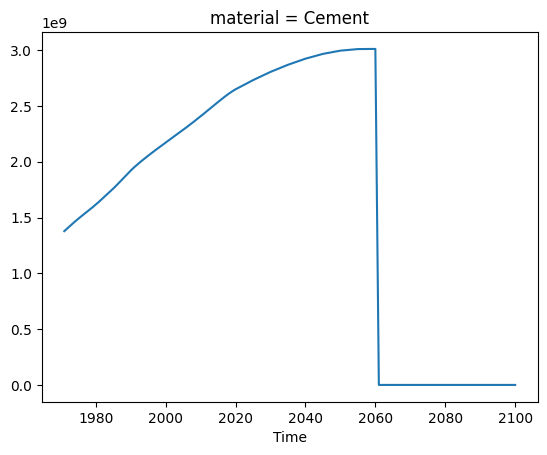

In [27]:
model.rest_of.get('inflow_materials_rest').sel(material = 'Cement').sum('Region').plot()

In [26]:
# sum inflow materials for steel, sum also per types keep regions and year

materials_dict = {
    'Steel' : 'Steel',
    'Aluminium' : 'Aluminium',
    'Copper' : 'Cu'
}

def sum_inflows_for_output(materials_dict):
    for key, value in materials_dict.items():
        inflow_buildings = model.buildings.get('inflow_materials').to_array().sum(['Type']).sel(material=key).loc[1961:]
        inflow_vehicles = model.vehicles.get('inflow_materials').to_array().sum(['Type']).sel(material=value).loc[1961:]

        total_material = inflow_buildings + inflow_vehicles

        # from total_material create a csv that has the years as rows and regions as columns, mae sure that region names are no just '1' but 'class_ 1'
        # also drop material dimension
        if key != 'Copper':
            total_material = total_material.drop_vars('material')
        # change the region coordinate so that it is class_ 1 instead of 1 , ...
        # Get the current region values
        regions = total_material.coords['Region'].values

        # Create new region names
        new_regions = [f'class_ {r}' for r in regions]

        # Assign the new region names to the coordinate
        total_material = total_material.assign_coords(Region=new_regions)
        # to t
        total_material = total_material.pint.to('t')
        # save as pandas to save as csv
        total_material = total_material.rename("total_material")
        total_material.to_dataframe().unstack().to_csv(f'total_material_{key}.csv')
        print('done', key)
    return total_material


sum_inflows_for_output(materials_dict)


AttributeError: 'NoneType' object has no attribute 'to_array'